<a href="https://colab.research.google.com/github/Yehmeg/Research_project1/blob/main/final_phishingdetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & import packages

In [ ]:
!pip install scikit-learn joblib


In [ ]:
import re
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV


Text cleaner

In [ ]:
class SimpleTextCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, lower=True, strip_html=True, remove_urls=True, remove_emails=True):
        self.lower = lower
        self.strip_html = strip_html
        self.remove_urls = remove_urls
        self.remove_emails = remove_emails
        self._html = re.compile(r"<.*?>")
        self._url = re.compile(r"https?://\S+|www\.\S+")
        self._email = re.compile(r"\b[\w\.-]+?@[\w\.-]+\.\w+\b")

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        cleaned = []
        for t in X:
            if pd.isna(t):
                t = ""
            s = str(t)
            if self.lower: s = s.lower()
            if self.strip_html: s = self._html.sub(" ", s)
            if self.remove_urls: s = self._url.sub(" ", s)
            if self.remove_emails: s = self._email.sub(" ", s)
            s = re.sub(r"\s+", " ", s).strip()
            cleaned.append(s)
        return cleaned


Label conversion helper

In [ ]:

def coerce_labels(col):
    return col.map({
        "Safe Email": 0,
        "Phishing Email": 1
    }).values   # returns numpy array

    def to01(v):
        s = str(v).strip().lower()
        if s in mapping:
            return mapping[s]
        try:
            return 1 if int(float(s)) > 0 else 0
        except:
            return 0
    return y.map(to01).astype(int).values

Build models

In [ ]:
def build_rf_pipeline(max_features=50000):
    return Pipeline([
        ("clean", SimpleTextCleaner()),
        ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=max_features,
                                  min_df=2, stop_words="english")),
        ("clf", RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                       n_jobs=-1, random_state=42))
    ])

def build_stacked_pipeline(max_features=50000):
    base_lr = LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")
    base_svc = CalibratedClassifierCV(
        estimator=LinearSVC(class_weight="balanced", random_state=42), # Changed from base_estimator to estimator
        method="sigmoid", cv=3
    )
    base_nb = MultinomialNB(alpha=0.5)

    stack = StackingClassifier(
        estimators=[("lr", base_lr), ("svm", base_svc), ("nb", base_nb)],
        final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear"),
        cv=5, n_jobs=-1
    )

    return Pipeline([
        ("clean", SimpleTextCleaner()),
        ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=max_features,
                                  min_df=2, stop_words="english")),
        ("clf", stack)
    ])

In [ ]:
import csv, sys
csv.field_size_limit(sys.maxsize)   # or csv.field_size_limit(10**9)

import pandas as pd
df = pd.read_csv("/content/Phishing_Email.csv", dtype=str, engine='python')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  object
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: object(3)
memory usage: 437.2+ KB


Train & evaluate

In [ ]:
# Use correct columns
text_col = "Email Text"
label_col = "Email Type"

X = df[text_col].astype(str).fillna("")
y_raw = df[label_col]

# FIX: ensure y stays a Pandas Series
y = pd.Series(coerce_labels(y_raw), index=df.index)

# Show label distribution
print("Label distribution after mapping:")
print(y.value_counts(dropna=False))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = build_stacked_pipeline()
model.fit(X_train, y_train)

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
print(confusion_matrix(y_test, y_pred))


Label distribution after mapping:
0    11322
1     7328
Name: count, dtype: int64
              precision    recall  f1-score   support

           0     0.9833    0.9642    0.9737      2264
           1     0.9464    0.9748    0.9603      1466

    accuracy                         0.9684      3730
   macro avg     0.9648    0.9695    0.9670      3730
weighted avg     0.9688    0.9684    0.9684      3730

[[2183   81]
 [  37 1429]]


In [ ]:




live_emails = [
    # 1. Classic phishing
    "Your PayPal account has been limited. Click here immediately to restore access: http://paypal-verify.com/login",

    # 2. Harmless work email
    "Team, please find attached the minutes of today's meeting. Let me know if any corrections are needed.",

    # 3. Fake lottery scam
    "Congratulations! You have won $1,000,000 in the international lottery. Provide your bank details to claim.",

    # 4. Normal newsletter
    "Welcome to our monthly tech newsletter. This edition covers Python tips, AI research updates, and upcoming events."
]


X_live = pd.Series(live_emails)

# Predict
pred_labels = model.predict(X_live)
pred_probs = model.predict_proba(X_live)

# Show results
for email, label, prob in zip(live_emails, pred_labels, pred_probs):
    print("\nEmail:", email)
    print("Predicted:", "Phishing" if label == 1 else "Safe")
    print(f"Phishing probability: {prob[1]:.4f}")
    print(f"Safe probability: {prob[0]:.4f}")



Email: Your PayPal account has been limited. Click here immediately to restore access: http://paypal-verify.com/login
Predicted: Phishing
Phishing probability: 0.9983
Safe probability: 0.0017

Email: Team, please find attached the minutes of today's meeting. Let me know if any corrections are needed.
Predicted: Safe
Phishing probability: 0.0058
Safe probability: 0.9942

Email: Congratulations! You have won $1,000,000 in the international lottery. Provide your bank details to claim.
Predicted: Phishing
Phishing probability: 0.9978
Safe probability: 0.0022

Email: Welcome to our monthly tech newsletter. This edition covers Python tips, AI research updates, and upcoming events.
Predicted: Safe
Phishing probability: 0.0324
Safe probability: 0.9676


In [ ]:
def check_mail(email_text):
    """
    Check if an email is phishing or safe.
    Input: single email text (string)
    Output: prediction + probabilities
    """
    X_live = pd.Series([email_text])  # wrap as Series for pipeline
    pred_label = model.predict(X_live)[0]
    pred_prob = model.predict_proba(X_live)[0]


    print("Predicted:", "Phishing" if pred_label == 1 else "Safe")
    print(f"Phishing probability: {pred_prob[1]:.4f}")
    print(f"Safe probability: {pred_prob[0]:.4f}")


In [ ]:
check_mail('''
Welcome to our monthly tech newsletter with AI tips.''')

Predicted: Safe
Phishing probability: 0.4708
Safe probability: 0.5292


In [ ]:
check_mail('''Congratulations!
You have won a lottery. Send us your bank details."''')

Predicted: Phishing
Phishing probability: 0.9881
Safe probability: 0.0119


In [ ]:
check_mail("Hi team, please find attached the report for tomorrow’s meeting.")

Predicted: Safe
Phishing probability: 0.0054
Safe probability: 0.9946


In [ ]:
check_mail("Thank you for registering. Your Springer Nature account is now ready to use. If you need help with your account, please contact our support team")


Email: Thank you for registering. Your Springer Nature account is now ready to use. If you need help with your account, please contact our support team
Predicted: Phishing
Phishing probability: 0.9278
Safe probability: 0.0722


In [ ]:
check_mail("""ChatLLM gives you all the top LLMs, including GPT-5 Thinking, Sonnet 4, Grok 4, o3 Pro, GPT-5 Pro, and
Opus 4.1. You also get access to all the top image and video generators.Signup here at http://chatllm.abacus.aiYou also get
 access to DeepAgent, which lets you create presentations, apps, and connect to different systems and automate work.
  Last but not least, the humanize feature enables you to create content that is not detected by AI detectors!Sign up here
  - http://chatllm.abacus.aiYou can also read more about ChatLLM here - https://chatllm.abacus.ai/chat_llm_faq

""")


Email: ChatLLM gives you all the top LLMs, including GPT-5 Thinking, Sonnet 4, Grok 4, o3 Pro, GPT-5 Pro, and Opus 4.1. You also get access to all the top image and video generators.Signup here at http://chatllm.abacus.aiYou also get access to DeepAgent, which lets you create presentations, apps, and connect to different systems and automate work. Last but not least, the humanize feature enables you to create content that is not detected by AI detectors!Sign up here - http://chatllm.abacus.aiYou can also read more about ChatLLM here - https://chatllm.abacus.ai/chat_llm_faq


Predicted: Safe
Phishing probability: 0.1917
Safe probability: 0.8083


In [ ]:
check_mail(''' Hi
Here are some of the latest opportunities matching your preferences. Apply now''')


Email:  Hi
Here are some of the latest opportunities matching your preferences. Apply now
Predicted: Phishing
Phishing probability: 0.7020
Safe probability: 0.2980


In [ ]:
check_mail(''' Thank you for applying for your Experian Credit Report and Experian Credit Score.
Experian Credit Report is based on the data that we collate from our member banks / financial institutions with whom you have
 an existing credit relationship and it provides information of your credit card or loan accounts including your re-payment behaviour
  in the past 36 months.
On the basis of the information submitted by our member banks / financial institutions,
we regret to inform you that presently we do not have any records of your credit information in our database as on "Current Date".''')


Email:  Thank you for applying for your Experian Credit Report and Experian Credit Score.
Experian Credit Report is based on the data that we collate from our member banks / financial institutions with whom you have an existing credit relationship and it provides information of your credit card or loan accounts including your re-payment behaviour in the past 36 months.
On the basis of the information submitted by our member banks / financial institutions, we regret to inform you that presently we do not have any records of your credit information in our database as on "Current Date".
Predicted: Phishing
Phishing probability: 0.9939
Safe probability: 0.0061


In [ ]:
check_mail('''Hi

The OpenAI to Z Hackathon proved what happens when thousands of Kagglers tackle a challenge with creativity,
 collaboration and data. In this hackathon, over 8,000 Kagglers became modern-day digital explorers, using open data and
  AI models to uncover secrets of the Amazon rainforest and bring ancient legends to life. Some teams focused on predicting
  hidden archaeological sites, others experimented with new patterns in the data and a few surprised us with entirely new
   approaches to discovery.
There were more than 200 submissions, each representing a unique way to explore a complex problem. Hackathons like this
 aren’t just about accuracy - they’re about imagination, experimentation and collaboration. They create a portfolio of creative
  solutions, showing what’s possible when communities come together to explore a challenge from different angles.

The winning teams and projects have been announced, but the creativity and insights from all participants continue to inspire.
 You can explore all the writeups from the participants to see the wide range of ideas and approaches.

Explore Writeups
Your digital exploration continues! Kaggle will keep offering new hackathons to test ideas, collaborate and discover what’s
possible together.''')

Predicted: Safe
Phishing probability: 0.1169
Safe probability: 0.8831


In [ ]:

check_mail('''Hi Learner,
We are pleased to inform you that Birchwood University’s Doctor of Business Administration (DBA) program has opened
 limited scholarship opportunities for select applicants.

This program is designed for professionals like you who want to:
Earn a doctorate while working — flexible structure tailored for executives
Strengthen leadership expertise with global business insights
Enhance career opportunities in academia, consulting, and corporate leadership
Start your application today and take the first step toward transforming your career with a prestigious,
 Fully online DBA degree from Birchwood University.''')

Predicted: Phishing
Phishing probability: 0.9834
Safe probability: 0.0166


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# Print matrix values
print("Confusion Matrix:")
print(cm)




Confusion Matrix:
[[2183   81]
 [  37 1429]]


<Figure size 600x400 with 0 Axes>

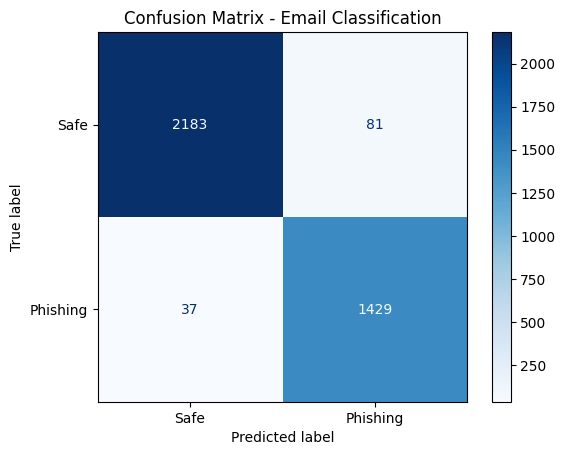

In [ ]:
# Plot heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe", "Phishing"])
plt.figure(figsize=(6,4))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Email Classification")
plt.show()

ROC AUC: 0.996201443556901


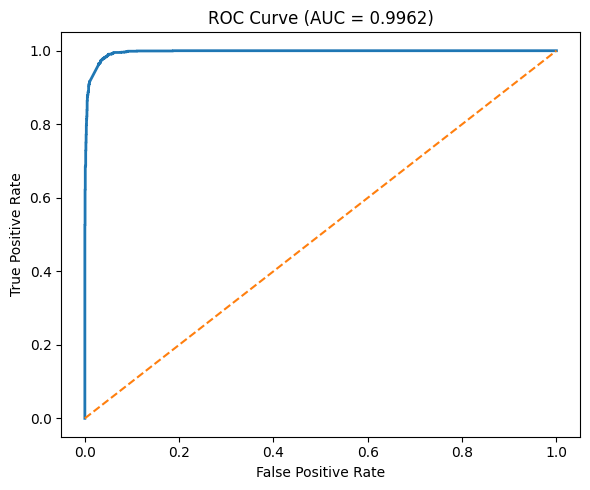

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities (class 1 = phishing)
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = {:.4f})".format(roc_auc))
plt.tight_layout()
plt.show()
